This notebook uses the visualisation functions of PyABC to plot the results of the parameter fitting to the Trp53 lineage tracing data.   

Before running this notebook, the ABC fitting should be run using the trp53TakeoverFittingFirstTimepoints.py script, 
which will produce the file `Trp53First.db`

# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib

In [2]:
import os
from pyabc.visualization import plot_kde_2d, plot_kde_matrix, plot_kde_1d, plot_credible_intervals
from pyabc import History

In [3]:
from pyabc.visualization.credible import compute_credible_interval, compute_kde_max, compute_quantile

In [4]:
from collections import OrderedDict

In [5]:
def get_inferred_fit(df, w):
    median_fitness = compute_quantile(np.array(df['fitness']), w, alpha=0.5)
    median_induction = compute_quantile(np.array(df['induction']), w, alpha=0.5)
    print('median fitness', median_fitness)
    print('median induction', median_induction)
    print('95CI fitness', compute_credible_interval(np.array(df['fitness']), w))
    print('95CI induction', compute_credible_interval(np.array(df['induction']), w))
    return {'fitness': median_fitness, 'induction': median_induction}

In [6]:
limits = {"fitness": [0, 50], "induction": [0, 0.1]}  # These were the ranges of the prior parameter distributions

# Load inference

In [7]:
db_path = "sqlite:///" + "Trp53First_pyabc.db"
hist_het = History(db_path)
df_het, w_het = hist_het.get_distribution(m=0)

In [8]:
HET_PARAMS = get_inferred_fit(df_het, w_het);

median fitness 1.5705956848935803
median induction 0.002054218150205822
95CI fitness (np.float64(1.435483285367668), np.float64(1.7454204690609154))
95CI induction (np.float64(0.001453470644617032), np.float64(0.002720644488971947))


# Plots

In [9]:
all_results = OrderedDict([
    ('Trp53', (df_het, w_het)),
]
)

## Fitness credible intervals

In [10]:
ticks = []
bottoms = []
tops = []
medians = []
for k, (df, w) in all_results.items():
    ci_l, ci_u = compute_credible_interval(np.array(df['fitness']), w)
    median = compute_quantile(np.array(df['fitness']), w, alpha=0.5)
    ticks.append(k)
    bottoms.append(ci_l)
    tops.append(ci_u)
    medians.append(median)

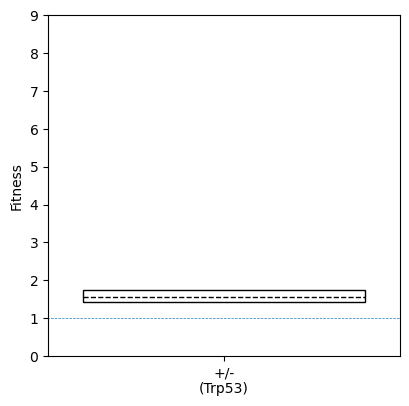

In [11]:
plt.figure(figsize=(4.2, 4))
plt.bar(range(1), np.array(tops)-np.array(bottoms), bottom=bottoms, facecolor='w', edgecolor='k', linestyle='-')
for i, m in enumerate(medians):
    plt.plot([i-0.4, i+0.4], [m, m], c='k', linestyle='--', linewidth=1)
plt.ylim(bottom=0)
plt.yticks(range(10))
plt.hlines(1, -1, 10, linestyles='--', linewidth=0.5)
plt.xlim([-0.5, 0.5])
plt.ylim(bottom=0)
plt.ylabel('Fitness')
plt.tight_layout()
plt.xticks(range(1), ['+/-\n(Trp53)']);

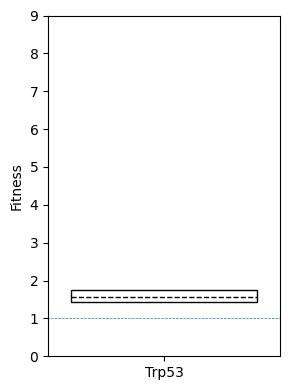

In [12]:
# Version with just WT, iHET and iHOM
plt.figure(figsize=(3, 4))
tops2 = np.array(tops)
bottoms2 = np.array(bottoms)
medians2 = np.array(medians)

plt.bar(range(1), np.array(tops2)-np.array(bottoms2), bottom=bottoms2, facecolor='w', edgecolor='k', linestyle='-')
for i, m in enumerate(medians2):
    plt.plot([i-0.4, i+0.4], [m, m], c='k', linestyle='--', linewidth=1)
plt.ylim(bottom=0)
plt.yticks(range(10))
plt.hlines(1, -1, 10, linestyles='--', linewidth=0.5)
plt.xlim([-0.5, 0.5])
plt.ylim(bottom=0)
plt.ylabel('Fitness')
plt.xticks(range(1), ['Trp53',])
plt.tight_layout()
plt.savefig("ABC_inferred_fitness.pdf");

# All results on the fitness-induction plane

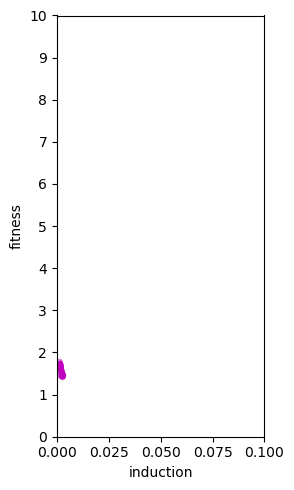

In [13]:
plt.figure(figsize=(3, 5))
plt.scatter(df_het['induction'], df_het['fitness'], s=w_het*1000, alpha=0.3, c='m')
plt.ylim([0, 10])
plt.xlim([0, 0.1])
plt.yticks(range(11))
plt.xlabel('induction') 
plt.ylabel('fitness')
plt.tight_layout()
plt.savefig("ABC_inferred_fitness_induction.pdf");

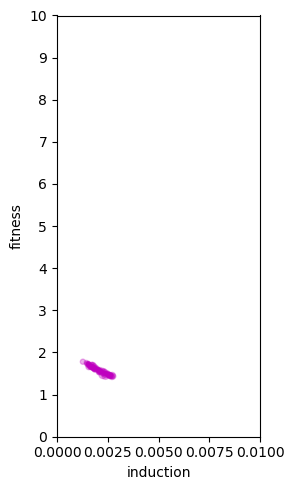

In [14]:
# Zoom in 
plt.figure(figsize=(3, 5))
plt.scatter(df_het['induction'], df_het['fitness'], s=w_het*1000, alpha=0.3, c='m')
plt.ylim([0, 2])
plt.xlim([0, 0.01])
plt.yticks(range(11))
plt.xlabel('induction') 
plt.ylabel('fitness')
plt.tight_layout()
plt.savefig("ABC_inferred_fitness_induction.pdf");